In [ ]:
# ===== ENVIRONMENT SETUP =====
# This notebook requires the following Python packages:
# - astropy
# - photutils
# - plotly
# - batman-package
#
# These can be installed using:
# pip install astropy photutils plotly batman-package
#
# (Installation is not performed automatically to ensure compatibility across environments)

In [32]:
# ===== IMPORTS =====

# --- Standard library ---
import os
import glob
import re

# --- Data handling ---
import pandas as pd
import numpy as np

# --- Plotting ---
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go

# --- Astronomy / FITS handling ---
from astropy.io import fits

# --- Photometry ---
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from scipy.signal import fftconvolve

# --- Transit modeling ---
import batman

# --- Signal processing ---
from scipy.ndimage import median_filter

# --- Optimization ---
from scipy.optimize import curve_fit

# --- Path handling (for GitHub portability) ---
from pathlib import Path

In [33]:
# ----- TRANSIT DATA SETUP & FILE INSPECTION -----

# Base directory
BASE_PATH = Path().resolve().parent

# Data path (KeplerCam night)
DATA_PATH = BASE_PATH / "data" / "KeplerCam" / "2026-03-18"

# ----- Load file lists (filter by filename patterns) -----
bias_files = sorted(DATA_PATH.glob("*BIAS*.fits"))
flat_files = sorted(DATA_PATH.glob("*FLAT*.fits"))
science_files = sorted(DATA_PATH.glob("*HAT-P-36b*.fits"))

# ----- Sanity check -----
print(f"Bias frames:    {len(bias_files)}")
print(f"Flat frames:    {len(flat_files)}")
print(f"Science frames: {len(science_files)}")

if not science_files:
    raise FileNotFoundError("No science files found")

# ----- Inspect sample science file -----
test_file = science_files[0]

with fits.open(test_file) as hdul:
    print(f"\nFile: {test_file.name}")
    print(f"Number of HDUs: {len(hdul)}\n")

    for i, hdu in enumerate(hdul):
        shape = None if hdu.data is None else hdu.data.shape
        print(f"HDU {i}: type={type(hdu).__name__}, name={hdu.name}, shape={shape}")

# ----- Extract header info -----
with fits.open(test_file) as hdul:
    hdr = hdul[0].header

important_keys = [
    "OBJECT", "FILTER", "EXPTIME", "DATE-OBS",
    "MJD", "JD", "IMAGETYP", "AIRMASS", "RA", "DEC"
]

print("\n----- HEADER INFO -----")
for key in important_keys:
    if key in hdr:
        print(f"{key:10s} = {hdr[key]}")

Bias frames:    10
Flat frames:    9
Science frames: 600

File: 0144.HAT-P-36b.fits
Number of HDUs: 5

HDU 0: type=PrimaryHDU, name=PRIMARY, shape=None
HDU 1: type=ImageHDU, name=IM1, shape=(1025, 1040)
HDU 2: type=ImageHDU, name=IM2, shape=(1025, 1040)
HDU 3: type=ImageHDU, name=IM3, shape=(1025, 1040)
HDU 4: type=ImageHDU, name=IM4, shape=(1025, 1040)

----- HEADER INFO -----
OBJECT     = HAT-P-36b
FILTER     = r
EXPTIME    = 10.0
DATE-OBS   = 2026-03-19T05:03:23
MJD        = 61118.210683
IMAGETYP   = OBJECT
RA         = 12:33:03.89
DEC        = 44:54:55


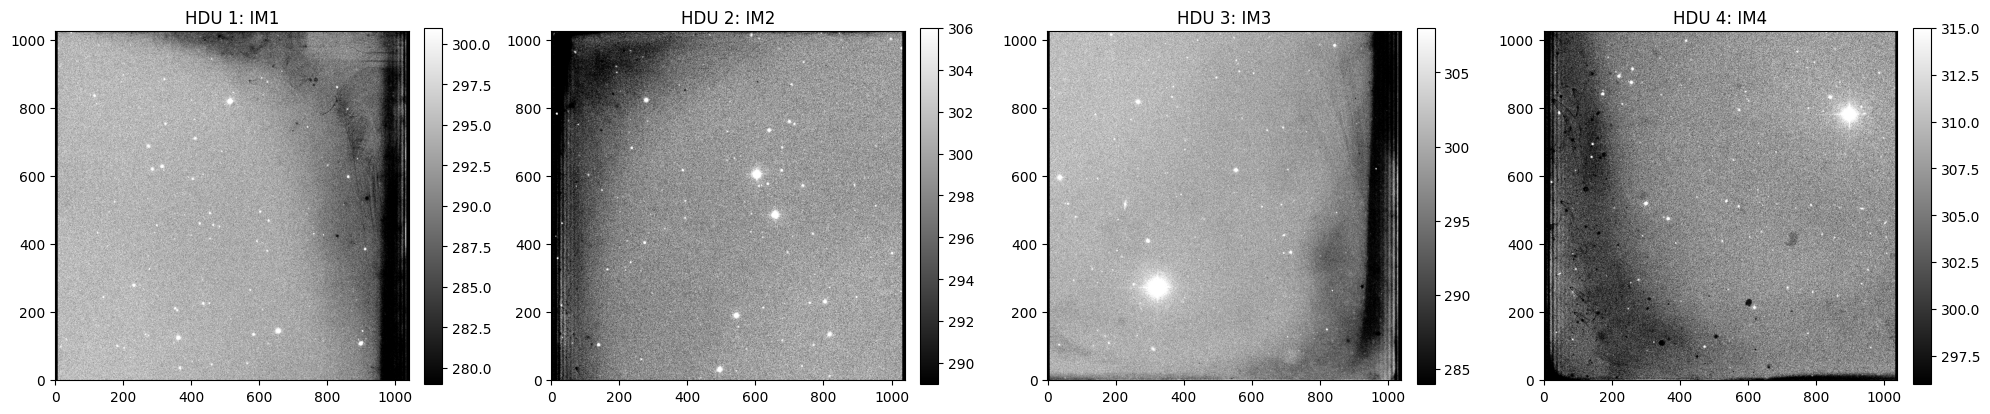

In [34]:
# ----- VISUALIZE SCIENCE FRAMES (HDU INSPECTION) -----

# Identify image HDUs (ignore non-2D or empty)
with fits.open(test_file) as hdul:
    image_hdus = [i for i, hdu in enumerate(hdul) if hdu.data is not None and hdu.data.ndim == 2]

# Create subplot layout
fig, axes = plt.subplots(1, len(image_hdus), figsize=(5 * len(image_hdus), 5))

# Ensure axes iterable
if len(image_hdus) == 1:
    axes = [axes]

# Plot each image HDU
with fits.open(test_file) as hdul:
    for ax, i in zip(axes, image_hdus):
        data = hdul[i].data

        vmin = np.percentile(data, 5)
        vmax = np.percentile(data, 99)

        im = ax.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(f"HDU {i}: {hdul[i].name}")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [35]:
# ----- BUILD METADATA TABLE FOR SCIENCE FRAMES -----

rows = []

# Extract relevant header information from each science frame
for f in science_files:
    with fits.open(f) as hdul:
        hdr = hdul[0].header

        rows.append({
            "filename": f.name,
            "object": hdr.get("OBJECT"),
            "filter": hdr.get("FILTER"),
            "exptime": hdr.get("EXPTIME"),
            "date_obs": hdr.get("DATE-OBS"),
            "mjd": hdr.get("MJD"),
            "jd": hdr.get("JD"),
            "imagetype": hdr.get("IMAGETYP")
        })

# Convert to DataFrame
science_df = pd.DataFrame(rows)

# Inspect
science_df.head()

,filename,object,filter,exptime,date_obs,mjd,jd,imagetype
0,0144.HAT-P-36b.fits,HAT-P-36b,r,10.0,2026-03-19T05:03:23,61118.210683,None,OBJECT
1,0145.HAT-P-36b.fits,HAT-P-36b,r,10.0,2026-03-19T05:03:44,61118.210926,None,OBJECT
2,0146.HAT-P-36b.fits,HAT-P-36b,r,10.0,2026-03-19T05:04:07,61118.211192,None,OBJECT
3,0147.HAT-P-36b.fits,HAT-P-36b,r,10.0,2026-03-19T05:04:29,61118.211447,None,OBJECT
4,0148.HAT-P-36b.fits,HAT-P-36b,r,10.0,2026-03-19T05:04:51,61118.211701,None,OBJECT


In [36]:
# ----- SORT SCIENCE FRAMES BY TIME -----

# Use best available time standard
if science_df["mjd"].notna().any():
    science_df = science_df.sort_values("mjd").reset_index(drop=True)
    time_used = "MJD"

elif science_df["jd"].notna().any():
    science_df = science_df.sort_values("jd").reset_index(drop=True)
    time_used = "JD"

elif science_df["date_obs"].notna().any():
    science_df = science_df.sort_values("date_obs").reset_index(drop=True)
    time_used = "DATE-OBS"

else:
    time_used = "NONE (no valid time field found)"

# Check result
print(f"Sorted using: {time_used}")
science_df[["filename", "filter", "exptime", "date_obs", "mjd", "jd"]].head(10)

Sorted using: MJD


,filename,filter,exptime,date_obs,mjd,jd
0,0144.HAT-P-36b.fits,r,10.0,2026-03-19T05:03:23,61118.210683,None
1,0145.HAT-P-36b.fits,r,10.0,2026-03-19T05:03:44,61118.210926,None
2,0146.HAT-P-36b.fits,r,10.0,2026-03-19T05:04:07,61118.211192,None
3,0147.HAT-P-36b.fits,r,10.0,2026-03-19T05:04:29,61118.211447,None
4,0148.HAT-P-36b.fits,r,10.0,2026-03-19T05:04:51,61118.211701,None
5,0149.HAT-P-36b.fits,r,10.0,2026-03-19T05:05:13,61118.211956,None
6,0150.HAT-P-36b.fits,r,10.0,2026-03-19T05:05:34,61118.212199,None
7,0151.HAT-P-36b.fits,r,10.0,2026-03-19T05:05:57,61118.212465,None
8,0152.HAT-P-36b.fits,r,10.0,2026-03-19T05:06:19,61118.212720,None
9,0153.HAT-P-36b.fits,r,10.0,2026-03-19T05:06:41,61118.212975,None


Master bias created. Shape: (1025, 930)


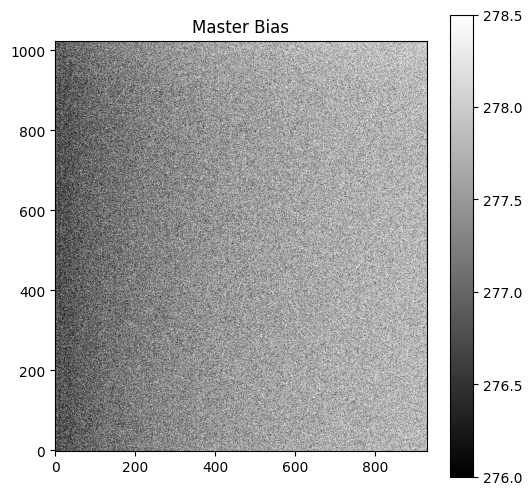

In [37]:
# ----- BUILD MASTER BIAS FRAME -----

# Trimming parameters
left_trim = 100
right_trim = 10
SCI_EXT = 2

bias_stack = []

# Load and process bias frames
for f in bias_files:
    with fits.open(f) as hdul:
        data = hdul[SCI_EXT].data.astype(float)

        # Trim edge columns
        data_trim = data[:, left_trim:-right_trim]

        bias_stack.append(data_trim)

# Median combine
bias_stack = np.array(bias_stack)

if bias_stack.size == 0:
    raise ValueError("Bias stack is empty")

master_bias = np.median(bias_stack, axis=0)

print(f"Master bias created. Shape: {master_bias.shape}")

# ----- VISUALIZE MASTER BIAS -----

plt.figure(figsize=(6, 6))
plt.imshow(
    master_bias,
    origin='lower',
    cmap='gray',
    vmin=np.percentile(master_bias, 5),
    vmax=np.percentile(master_bias, 95)
)

plt.title("Master Bias")
plt.colorbar()
plt.show()

Master flat created. Shape: (1025, 930)


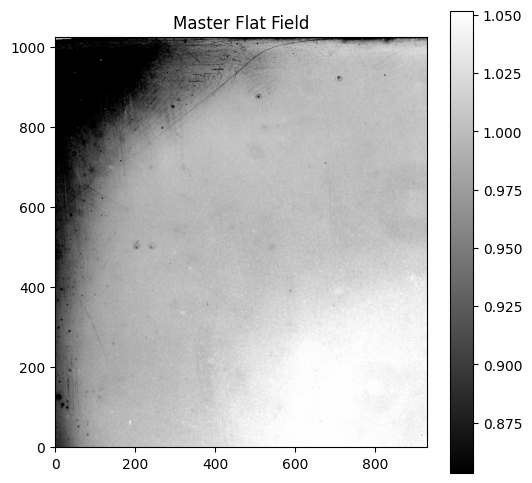

In [38]:
# ----- BUILD MASTER FLAT FIELD -----

flat_stack = []

# Load and process flat frames
for f in flat_files:
    with fits.open(f) as hdul:
        data = hdul[SCI_EXT].data.astype(float)

        # Trim edge columns
        data_trim = data[:, left_trim:-right_trim]

        # Subtract master bias
        data_trim = data_trim - master_bias

        flat_stack.append(data_trim)

# Median combine
flat_stack = np.array(flat_stack)

if flat_stack.size == 0:
    raise ValueError("Flat stack is empty")

master_flat = np.median(flat_stack, axis=0)

# Normalize
master_flat = master_flat / np.median(master_flat)

# Protect against low-response pixels
master_flat[master_flat < 0.5] = 1

print(f"Master flat created. Shape: {master_flat.shape}")

# ----- VISUALIZE MASTER FLAT -----

plt.figure(figsize=(6, 6))
plt.imshow(
    master_flat,
    origin='lower',
    cmap='gray',
    vmin=np.percentile(master_flat, 5),
    vmax=np.percentile(master_flat, 95)
)

plt.title("Master Flat Field")
plt.colorbar()
plt.show()

Calibrated test frame: 0144.HAT-P-36b.fits
Reduced shape: (1025, 930)


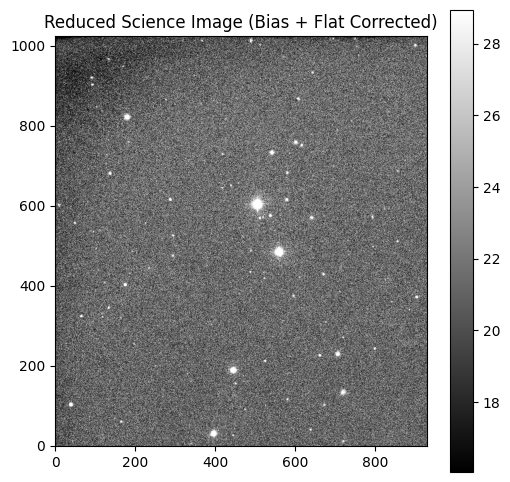

In [39]:
# ----- APPLY CALIBRATIONS TO A SINGLE SCIENCE FRAME (TEST) -----

# Select a test science frame
test_file = science_files[0]

# Load data
with fits.open(test_file) as hdul:
    data = hdul[SCI_EXT].data.astype(float)

# Trim edge columns
data_trim = data[:, left_trim:-right_trim]

# Apply calibration: (science - bias) / flat
reduced = (data_trim - master_bias) / master_flat

print(f"Calibrated test frame: {test_file.name}")
print(f"Reduced shape: {reduced.shape}")

# ----- VISUALIZE REDUCED SCIENCE FRAME -----

plt.figure(figsize=(6, 6))
plt.imshow(
    reduced,
    origin='lower',
    cmap='gray',
    vmin=np.percentile(reduced, 5),
    vmax=np.percentile(reduced, 99)
)

plt.title("Reduced Science Image (Bias + Flat Corrected)")
plt.colorbar()
plt.show()

In [40]:
# ----- DEFINE TARGET AND COMPARISON STAR POSITIONS -----

# Format: [x, y] pixel coordinates
positions = np.array([
    [560, 485],  # target star (HAT-P-36)
    [505, 605],  # comparison star 1
    [180, 820],  # comparison star 2
    [445, 190],  # comparison star 3
    [705, 230]   # comparison star 4
], dtype=float)

print(f"Number of stars selected: {len(positions)}")

# Separate for clarity (useful later)
target_pos = positions[0]
comp_positions = positions[1:]

print(f"Target position: {target_pos}")
print(f"Number of comparison stars: {len(comp_positions)}")

Number of stars selected: 5
Target position: [560. 485.]
Number of comparison stars: 4


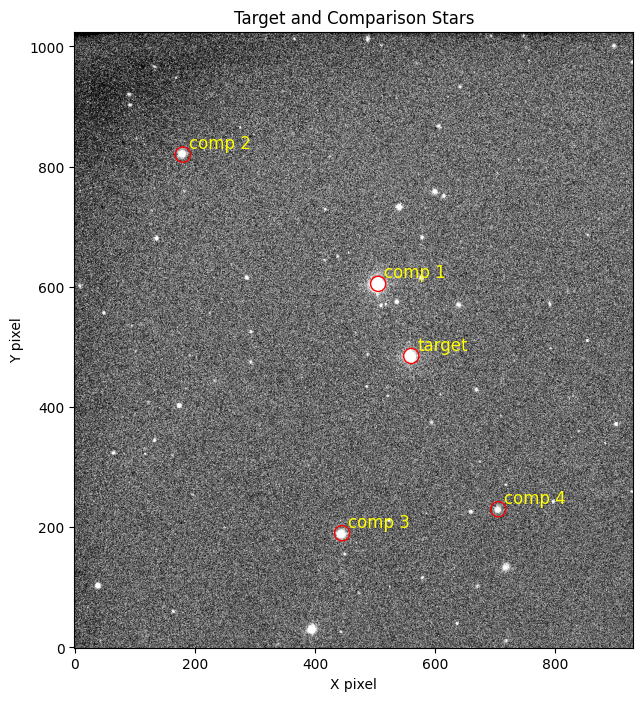

In [41]:
# ----- VISUALIZE TARGET + COMPARISON STARS ON IMAGE -----

plt.figure(figsize=(8, 8))

# Show calibrated image
plt.imshow(
    reduced,
    origin='lower',
    cmap='gray',
    vmin=np.percentile(reduced, 5),
    vmax=np.percentile(reduced, 99)
)

# Overlay star positions
plt.scatter(
    positions[:, 0],
    positions[:, 1],
    s=120,
    facecolors='none',
    edgecolors='red'
)

# Label stars
for i, (x, y) in enumerate(positions):
    label = "target" if i == 0 else f"comp {i}"
    plt.text(x + 10, y + 10, label, color='yellow', fontsize=12)

plt.title("Target and Comparison Stars")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")

plt.show()

In [42]:
# ----- DEFINE APERTURE PHOTOMETRY PARAMETERS -----

# Aperture radius (captures star flux)
ap_radius = 7

# Annulus radii (for background estimation)
annulus_r_in = 12
annulus_r_out = 18

# Define apertures and background annuli
apertures = CircularAperture(positions, r=ap_radius)
annuli = CircularAnnulus(positions, r_in=annulus_r_in, r_out=annulus_r_out)

print("Aperture and annulus regions defined")
print(f"Aperture radius: {ap_radius} px")
print(f"Annulus: {annulus_r_in}–{annulus_r_out} px")

Aperture and annulus regions defined
Aperture radius: 7 px
Annulus: 12–18 px


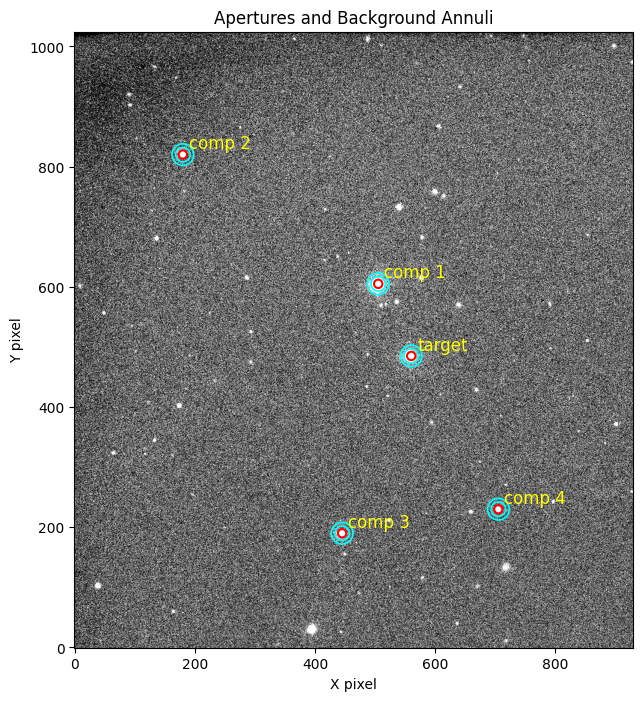

In [43]:
# ----- VISUALIZE APERTURES AND BACKGROUND ANNULI -----

plt.figure(figsize=(8, 8))

# Show calibrated image
plt.imshow(
    reduced,
    origin='lower',
    cmap='gray',
    vmin=np.percentile(reduced, 5),
    vmax=np.percentile(reduced, 99)
)

# Overlay apertures (star flux)
apertures.plot(color='red', lw=1.5)

# Overlay annuli (background region)
annuli.plot(color='cyan', lw=1.2)

# Label stars
for i, (x, y) in enumerate(positions):
    label = "target" if i == 0 else f"comp {i}"
    plt.text(x + 10, y + 10, label, color='yellow', fontsize=12)

plt.title("Apertures and Background Annuli")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")

plt.show()

In [14]:
# ----- PERFORM APERTURE PHOTOMETRY (SINGLE FRAME TEST) -----

# Compute aperture sums (star + background)
phot_ap = aperture_photometry(reduced, apertures)
phot_an = aperture_photometry(reduced, annuli)

# Convert to arrays
ap_sums = np.array(phot_ap['aperture_sum'])
an_sums = np.array(phot_an['aperture_sum'])

# Estimate background per pixel from annulus
bkg_means = an_sums / annuli.area

# Estimate total background inside aperture
bkg_in_ap = bkg_means * apertures.area

# Subtract background to get net flux
net_flux = ap_sums - bkg_in_ap

print("Aperture photometry results:")
print(f"Target flux: {net_flux[0]}")
print(f"Comparison fluxes: {net_flux[1:]}")

# Optional: quick sanity check
for i, flux in enumerate(net_flux):
    label = "target" if i == 0 else f"comp {i}"
    print(f"{label}: {flux:.2f}")

Aperture photometry results:
Target flux: 175884.78816358573
Comparison fluxes: [287680.17944369  29419.16801304  48243.84217487  12872.94724205]
target: 175884.79
comp 1: 287680.18
comp 2: 29419.17
comp 3: 48243.84
comp 4: 12872.95


In [15]:
# ----- COMPUTE RELATIVE FLUX (TARGET / COMPARISON STARS) -----

# Separate target and comparison stars
target_flux = net_flux[0]
comparison_flux = np.sum(net_flux[1:])

# Compute normalized (relative) flux
if comparison_flux <= 0:
    raise ValueError("Comparison flux is zero or negative — check apertures/background")

relative_flux = target_flux / comparison_flux

# Output values
print(f"Target flux: {target_flux:.2f}")
print(f"Comparison sum: {comparison_flux:.2f}")
print(f"Relative flux: {relative_flux:.6f}")

Target flux: 175884.79
Comparison sum: 378216.14
Relative flux: 0.465038


Frames kept: 600


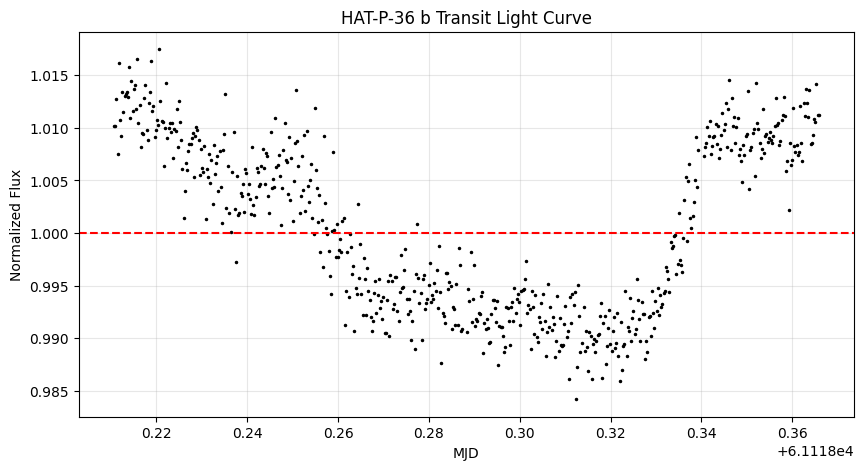

In [17]:
# ----- BUILD TRANSIT LIGHT CURVE (FULL PIPELINE) -----

# Storage
mjd_list = []
rel_flux_list = []

# Reference frame for image alignment
with fits.open(science_files[0]) as hdul:
    ref = hdul[SCI_EXT].data.astype(float)

ref = ref[:, left_trim:-right_trim]
ref = (ref - master_bias) / master_flat

# Photometry parameters
ap_radius = 10
ann_in = 15
ann_out = 25

# Loop over all science frames
for f in science_files:
    with fits.open(f) as hdul:
        hdr = hdul[0].header
        data = hdul[SCI_EXT].data.astype(float)

    # Calibrate image
    img = data[:, left_trim:-right_trim]
    img = (img - master_bias) / master_flat

    # Image alignment (shift correction)
    corr = fftconvolve(img, ref[::-1, ::-1], mode='same')
    y_shift, x_shift = np.unravel_index(np.argmax(corr), corr.shape)

    y_shift = y_shift - img.shape[0] // 2
    x_shift = x_shift - img.shape[1] // 2

    shifted_positions = positions + np.array([x_shift, y_shift])

    # Aperture photometry
    apertures = CircularAperture(shifted_positions, r=ap_radius)
    annuli = CircularAnnulus(shifted_positions, r_in=ann_in, r_out=ann_out)

    phot_ap = aperture_photometry(img, apertures)
    phot_an = aperture_photometry(img, annuli)

    ap_sums = np.array(phot_ap["aperture_sum"], dtype=float)
    an_sums = np.array(phot_an["aperture_sum"], dtype=float)

    # Background subtraction
    bkg = (an_sums / annuli.area) * apertures.area
    net = ap_sums - bkg

    # Relative flux
    target = net[0]
    comp = np.sum(net[1:])

    if not np.isfinite(target) or not np.isfinite(comp) or comp <= 0:
        continue

    rel_flux = target / comp

    # Store results
    if "MJD" in hdr:
        mjd_list.append(hdr["MJD"])
        rel_flux_list.append(rel_flux)

print("Frames kept:", len(rel_flux_list))

# Build final light curve
mjds = np.array(mjd_list)
flux = np.array(rel_flux_list)

# Sort by time
order = np.argsort(mjds)
mjds = mjds[order]
flux = flux[order]

# Normalize
norm_flux = flux / np.median(flux)

# Plot light curve
plt.figure(figsize=(10, 5))
plt.plot(mjds, norm_flux, "k.", markersize=3)
plt.axhline(1.0, color="red", linestyle="--")

plt.xlabel("MJD")
plt.ylabel("Normalized Flux")
plt.title("HAT-P-36 b Transit Light Curve")

plt.grid(True, alpha=0.3)
plt.show()

In [26]:
# ----- BIN LIGHT CURVE (REDUCE NOISE) -----

bin_size = 5

mjds_binned = []
flux_binned = []

for i in range(0, len(mjds), bin_size):
    mjds_binned.append(np.mean(mjds[i:i+bin_size]))
    flux_binned.append(np.mean(norm_flux[i:i+bin_size]))

mjds_binned = np.array(mjds_binned)
flux_binned = np.array(flux_binned)

Planet radius = 1.276 R_Jup


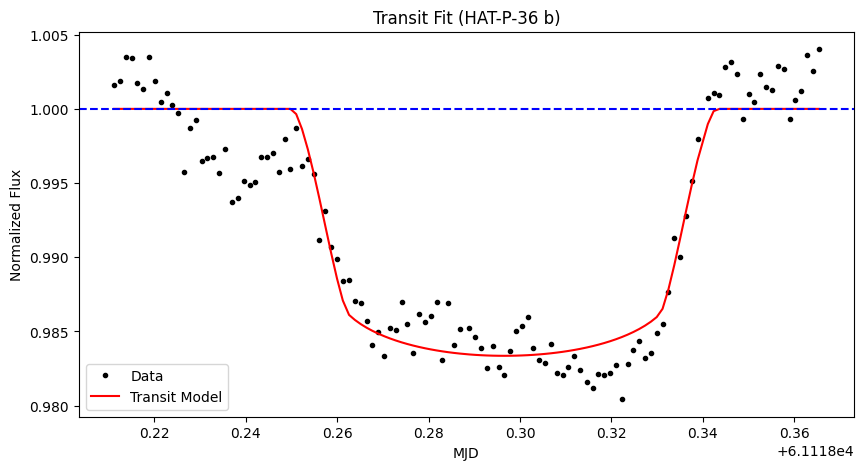

In [27]:
# ----- ESTIMATE HAT-P-36 b RADIUS AND TRANSIT DURATION -----

# Center time
t = mjds_binned - np.mean(mjds_binned)

# Identify out-of-transit (OOT)
oot_mask = np.abs(t) > 0.04

# Fit baseline using OOT only
coeffs = np.polyfit(t[oot_mask], flux_binned[oot_mask], deg=1)
baseline = np.polyval(coeffs, t)

# Normalize flux
flux = flux_binned / baseline
flux /= np.median(flux[oot_mask])

# Transit model setup
PERIOD = 1.327
INC = 85.0

def transit_model(t, t0, rp, a):
    params = batman.TransitParams()
    params.t0 = t0
    params.per = PERIOD
    params.rp = rp
    params.a = a
    params.inc = INC
    params.ecc = 0.0
    params.w = 90.0
    params.u = [0.3, 0.1]
    params.limb_dark = "quadratic"

    model = batman.TransitModel(params, t)
    return model.light_curve(params)

# Initial guesses
t0_guess = t[np.argmin(flux)]
rp_guess = 0.10
a_guess = 6.0

# Fit model
popt, _ = curve_fit(
    transit_model,
    t,
    flux,
    p0=[t0_guess, rp_guess, a_guess],
    maxfev=10000
)

t0_fit, rp_fit, a_fit = popt
model_flux = transit_model(t, t0_fit, rp_fit, a_fit)

# Convert to planet radius
R_star_Rsun = 1.041
Rsun_to_Rjup = 9.96

Rp_Rsun = rp_fit * R_star_Rsun
Rp_Rjup = Rp_Rsun * Rsun_to_Rjup

print(f"Planet radius = {Rp_Rjup:.3f} R_Jup")

# Plot in MJD
t_mjd = t + np.mean(mjds_binned)

plt.figure(figsize=(10, 5))
plt.plot(t_mjd, flux, "k.", label="Data")
plt.plot(t_mjd, model_flux, "r-", label="Transit Model")
plt.axhline(1.0, linestyle="--", color="blue")

plt.xlabel("MJD")
plt.ylabel("Normalized Flux")
plt.title("Transit Fit (HAT-P-36 b)")
plt.legend()

plt.show()